# Hledání optimálního modelu pro časovou řadu počtu přenocování turistů v České republice

**Předmět:** Časové řady  
**Téma:** Hledání optimálního modelu pro zvolenou časovou řadu  
**Hlavní řada:** `nights_CZ_total`, měsíční počet přenocování turistů v hromadných ubytovacích zařízeních v České republice


## 1. Úvod a cíl práce

Cílem práce je najít vhodný model pro měsíční časovou řadu počtu přenocování turistů v České republice. Řada je vhodná pro analýzu časových řad, protože má zřetelnou roční sezónnost, dlouhodobý trend a současně obsahuje mimořádný šok v období pandemie COVID-19.

Postupně budou použity grafická analýza, dekompozice, regresní modely s trendem a sezónností, SARIMA model, kroskorelační analýza s dalšími turistickými řadami, SARIMAX model s externími regresory, periodogram, diagnostika reziduí a predikce 10 budoucích pozorování.


## 2. Data a příprava dat

Data pocházejí z Eurostatu. Používají se dvě měsíční datové sady:

- `tour_occ_nim`: počet přenocování v hromadných ubytovacích zařízeních,
- `tour_occ_arm`: počet příjezdů do hromadných ubytovacích zařízení.

Hlavní analyzovanou řadou je `nights_CZ_total`. Jako možné vysvětlující řady se později použijí zejména příjezdy a přenocování v České republice a v sousedních zemích.


Následující blok načte knihovny a nastaví jednotný grafický styl. Varování jsou potlačena, aby notebook působil jako report; diagnostické výsledky jsou místo toho uváděny explicitně v tabulkách.


In [1]:
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
import requests
import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display
from scipy.signal import periodogram
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:,.3f}".format)


Tento blok stáhne z oficiálního Eurostat Dissemination API měsíční data pro Českou republiku a vybrané sousední země. Filtr je nastaven na celkové, domácí a zahraniční rezidenty od ledna 2013.


In [2]:
dataset_codes = ["tour_occ_nim", "tour_occ_arm"]
countries = ["CZ", "DE", "AT", "SK", "PL"]
resid_categories = ["TOTAL", "DOM", "FOR"]

EUROSTAT_BASE_URL = (
    "https://ec.europa.eu/eurostat/api/dissemination/"
    "statistics/1.0/data/{dataset_code}"
)


def fetch_eurostat_series(dataset_code, geo, c_resid):
    params = {
        "format": "JSON",
        "lang": "en",
        "freq": "M",
        "unit": "NR",
        "nace_r2": "I551-I553",
        "geo": geo,
        "c_resid": c_resid,
        "sinceTimePeriod": "2013-01",
    }
    response = requests.get(
        EUROSTAT_BASE_URL.format(dataset_code=dataset_code),
        params=params,
        timeout=60,
    )
    response.raise_for_status()
    payload = response.json()

    time_index = payload["dimension"]["time"]["category"]["index"]
    months = [
        month
        for month, _ in sorted(time_index.items(), key=lambda item: item[1])
    ]
    values = payload.get("value", {})

    row = {
        "freq": "M",
        "c_resid": c_resid,
        "unit": "NR",
        "nace_r2": "I551-I553",
        "geo\\TIME_PERIOD": geo,
    }
    for position, month in enumerate(months):
        row[month] = values.get(str(position), np.nan)
    return row


def load_eurostat_wide(dataset_code):
    rows = [
        fetch_eurostat_series(dataset_code, geo, c_resid)
        for c_resid in resid_categories
        for geo in countries
    ]
    return pd.DataFrame(rows)


nights_raw = load_eurostat_wide("tour_occ_nim")
arrivals_raw = load_eurostat_wide("tour_occ_arm")

raw_shapes = pd.DataFrame(
    {
        "dataset": ["tour_occ_nim", "tour_occ_arm"],
        "description": ["nights spent", "arrivals"],
        "rows": [nights_raw.shape[0], arrivals_raw.shape[0]],
        "columns": [nights_raw.shape[1], arrivals_raw.shape[1]],
    }
)

display(raw_shapes)


,dataset,description,rows,columns
0,tour_occ_nim,nights spent,15,164
1,tour_occ_arm,arrivals,15,164


Eurostat vrací data v širokém formátu, kde jsou jednotlivé měsíce ve sloupcích. Pro další práci se data převedou do dlouhého formátu, následně do měsíční pivot tabulky a spojí se řady přenocování a příjezdů.


In [3]:
def eurostat_wide_to_long(df, value_name):
    df = df.copy()
    geo_col = [col for col in df.columns if str(col).startswith("geo")][0]
    df = df.rename(columns={geo_col: "geo"})

    date_cols = [
        col for col in df.columns
        if re.match(r"^\d{4}-\d{2}$", str(col))
    ]
    id_vars = [col for col in df.columns if col not in date_cols]

    long_df = df.melt(
        id_vars=id_vars,
        value_vars=date_cols,
        var_name="date",
        value_name=value_name,
    )
    long_df["date"] = pd.to_datetime(long_df["date"])
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df


def make_pivot_table(long_df, value_col, prefix):
    pivot = long_df.pivot_table(
        index="date",
        columns=["geo", "c_resid"],
        values=value_col,
        aggfunc="first",
    )
    pivot.columns = [
        f"{prefix}_{geo}_{resid.lower()}"
        for geo, resid in pivot.columns
    ]
    return pivot.sort_index()


nights_long = eurostat_wide_to_long(nights_raw, "nights")
arrivals_long = eurostat_wide_to_long(arrivals_raw, "arrivals")

nights_pivot = make_pivot_table(nights_long, "nights", "nights")
arrivals_pivot = make_pivot_table(arrivals_long, "arrivals", "arrivals")

data = pd.concat([nights_pivot, arrivals_pivot], axis=1).asfreq("MS")
last_main_observation = data["nights_CZ_total"].last_valid_index()
data = data.loc[:last_main_observation]

data_overview = pd.DataFrame(
    {
        "value": [
            data.shape[0],
            data.shape[1],
            data.index.min().strftime("%Y-%m-%d"),
            data.index.max().strftime("%Y-%m-%d"),
        ]
    },
    index=["number_of_months", "number_of_series", "first_month", "last_month"],
)

display(data_overview)
display(data.head(3))
display(data.tail(3))


,value
number_of_months,158
number_of_series,30
first_month,2013-01-01
last_month,2026-02-01


,nights_AT_dom,nights_AT_for,nights_AT_total,nights_CZ_dom,nights_CZ_for,nights_CZ_total,nights_DE_dom,nights_DE_for,nights_DE_total,nights_PL_dom,...,arrivals_CZ_total,arrivals_DE_dom,arrivals_DE_for,arrivals_DE_total,arrivals_PL_dom,arrivals_PL_for,arrivals_PL_total,arrivals_SK_dom,arrivals_SK_for,arrivals_SK_total
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,"2,404,241.000","9,019,010.000","11,423,251.000","1,257,521.000","1,298,169.000","2,555,690.000","13,771,762.000","3,751,077.000","17,522,839.000","2,817,874.000",...,"852,860.000","6,287,043.000","1,668,360.000","7,955,403.000","1,083,432.000","269,077.000","1,352,509.000","147,663.000","105,083.000","252,746.000"
2013-02-01,"2,953,399.000","9,996,447.000","12,949,846.000","1,596,083.000","1,280,121.000","2,876,204.000","14,898,936.000","4,210,225.000","19,109,161.000","3,044,222.000",...,"923,105.000","6,818,611.000","1,851,813.000","8,670,424.000","1,121,674.000","242,462.000","1,364,136.000","175,436.000","110,012.000","285,448.000"
2013-03-01,"2,697,282.000","8,708,221.000","11,405,503.000","1,413,622.000","1,752,607.000","3,166,229.000","19,019,224.000","4,661,197.000","23,680,421.000","2,777,017.000",...,"1,120,874.000","8,466,313.000","2,089,240.000","10,555,553.000","1,128,827.000","361,248.000","1,490,075.000","189,921.000","118,298.000","308,219.000"


,nights_AT_dom,nights_AT_for,nights_AT_total,nights_CZ_dom,nights_CZ_for,nights_CZ_total,nights_DE_dom,nights_DE_for,nights_DE_total,nights_PL_dom,...,arrivals_CZ_total,arrivals_DE_dom,arrivals_DE_for,arrivals_DE_total,arrivals_PL_dom,arrivals_PL_for,arrivals_PL_total,arrivals_SK_dom,arrivals_SK_for,arrivals_SK_total
date,,,,,,,,,,,,,,,,,,,,,
2025-12-01,"2,510,765.000","9,353,904.000","11,864,669.000","1,449,215.000","2,437,060.000","3,886,275.000","21,323,353.000","6,582,972.000","27,906,325.000","5,196,225.000",...,"1,636,658.000","10,110,799.000","3,045,185.000","13,155,984.000","2,375,216.000","782,729.000","3,157,945.000","264,433.000","184,950.000","449,383.000"
2026-01-01,"2,813,754.000","10,876,566.000","13,690,320.000","1,834,671.000","1,691,734.000","3,526,405.000","16,963,901.000","4,277,203.000","21,241,104.000","5,268,349.000",...,"1,423,900.000","7,999,992.000","1,938,956.000","9,938,948.000","2,187,331.000","542,548.000","2,729,879.000","263,525.000","172,925.000","436,450.000"
2026-02-01,"3,137,200.000","11,496,876.000","14,634,076.000","2,154,877.000","1,827,668.000","3,982,545.000","18,207,151.000","5,078,278.000","23,285,429.000","5,772,903.000",...,"1,471,205.000","8,627,522.000","2,271,693.000","10,899,215.000","2,342,406.000","551,726.000","2,894,132.000","287,557.000","184,649.000","472,206.000"


Následující kontrola zjišťuje chybějící hodnoty. Hlavní řada nesmí obsahovat mezery; případné chybějící hodnoty v doplňkových řadách se doplní časovou interpolací, aby mohly být použity v kroskorelaci a SARIMAX modelech.


In [4]:
missing = data.isna().sum().sort_values(ascending=False)
missing_summary = missing[missing > 0].to_frame("missing_values")

display(missing_summary)

data_clean = data.copy()
data_clean = data_clean.interpolate(method="time").ffill().bfill()

y = data_clean["nights_CZ_total"]

cleaning_summary = pd.DataFrame(
    {
        "value": [
            int(data["nights_CZ_total"].isna().sum()),
            int(data.isna().sum().sum()),
            int(data_clean.isna().sum().sum()),
            y.index.min().strftime("%Y-%m-%d"),
            y.index.max().strftime("%Y-%m-%d"),
            len(y),
        ]
    },
    index=[
        "missing_in_main_series",
        "total_missing_before_cleaning",
        "total_missing_after_cleaning",
        "first_observation",
        "last_observation",
        "number_of_observations",
    ],
)

display(cleaning_summary)


,missing_values
arrivals_PL_for,1
arrivals_PL_total,1


,value
missing_in_main_series,0
total_missing_before_cleaning,2
total_missing_after_cleaning,0
first_observation,2013-01-01
last_observation,2026-02-01
number_of_observations,158


**Interpretace přípravy dat.** Výsledná tabulka obsahuje měsíční turistické řady pro několik zemí a rezidentských kategorií. Hlavní řada `nights_CZ_total` neobsahuje chybějící hodnoty, takže ji lze přímo modelovat. Interpolace se týká pouze doplňkových řad a její vliv je omezený, protože chybějících hodnot je málo.


## 3. Grafická analýza hlavní řady

Nejprve se zobrazí hlavní časová řada v milionech přenocování. Cílem je vizuálně identifikovat trend, sezónnost a mimořádná období.


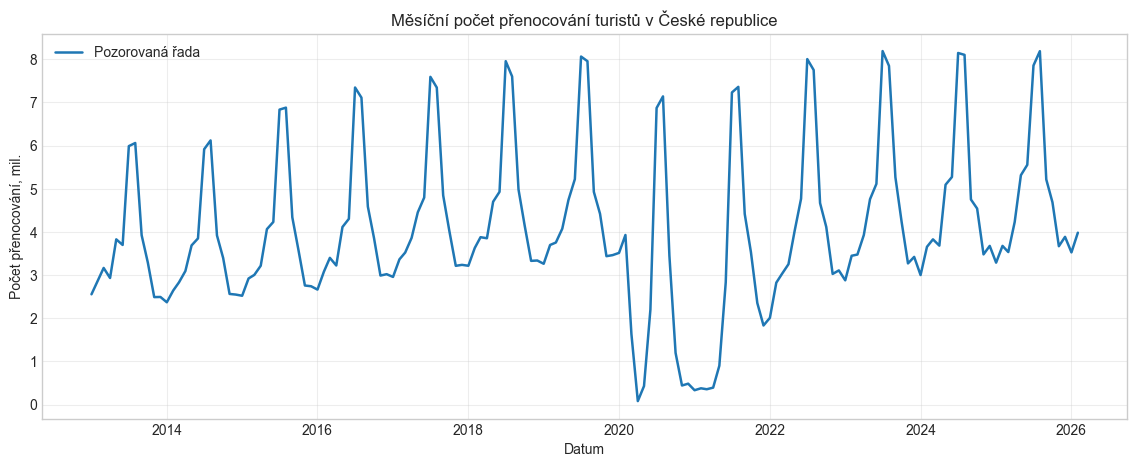

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Pozorovaná řada", linewidth=1.8)
plt.title("Měsíční počet přenocování turistů v České republice")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()


**Interpretace grafu.** Řada má výraznou roční sezónnost s maximy v letních měsících, zejména v červenci a srpnu. Do roku 2020 je patrný růst, poté přichází silný pandemický propad v letech 2020-2021 a následné zotavení. COVID období proto představuje strukturální zlom, který je nutné brát v úvahu při interpretaci modelů.


Další blok ukazuje typický sezónní profil podle měsíců. Průměry a boxplot pomáhají ověřit, zda je sezónnost stabilní a ve kterých měsících je nejvyšší variabilita.


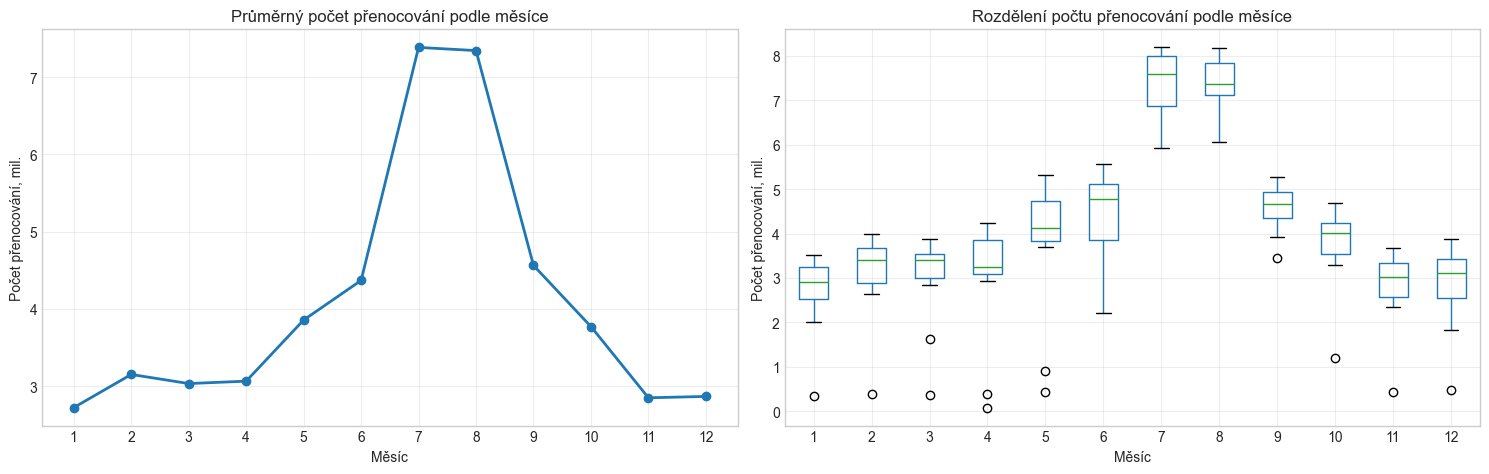

In [6]:
monthly_avg = y.groupby(y.index.month).mean() / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(monthly_avg.index, monthly_avg.values, marker="o", linewidth=2)
axes[0].set_title("Průměrný počet přenocování podle měsíce")
axes[0].set_xlabel("Měsíc")
axes[0].set_ylabel("Počet přenocování, mil.")
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.35)

season_df = pd.DataFrame({
    "nights_millions": y / 1_000_000,
    "month": y.index.month,
})
season_df.boxplot(column="nights_millions", by="month", ax=axes[1])
axes[1].set_title("Rozdělení počtu přenocování podle měsíce")
axes[1].set_xlabel("Měsíc")
axes[1].set_ylabel("Počet přenocování, mil.")
axes[1].grid(True, alpha=0.35)

fig.suptitle("")
plt.tight_layout()
plt.show()


**Interpretace sezónního profilu.** Letní měsíce mají systematicky nejvyšší hodnoty a zimní měsíce nejnižší hodnoty. Tvar sezónnosti není dokonale sinusový, protože letní špička je velmi výrazná; to je důvod, proč budou později vyzkoušeny Fourierovy členy s více harmonickými složkami.


## 4. Dekompozice a vyhlazení trendu

V této části se řada rozloží na trendovou, sezónní a reziduální složku. Používá se robustní STL dekompozice s periodou 12, protože data jsou měsíční a obsahují mimořádný pandemický šok. Pro kontrolu trendu se použije také centrovaný 12měsíční klouzavý průměr.


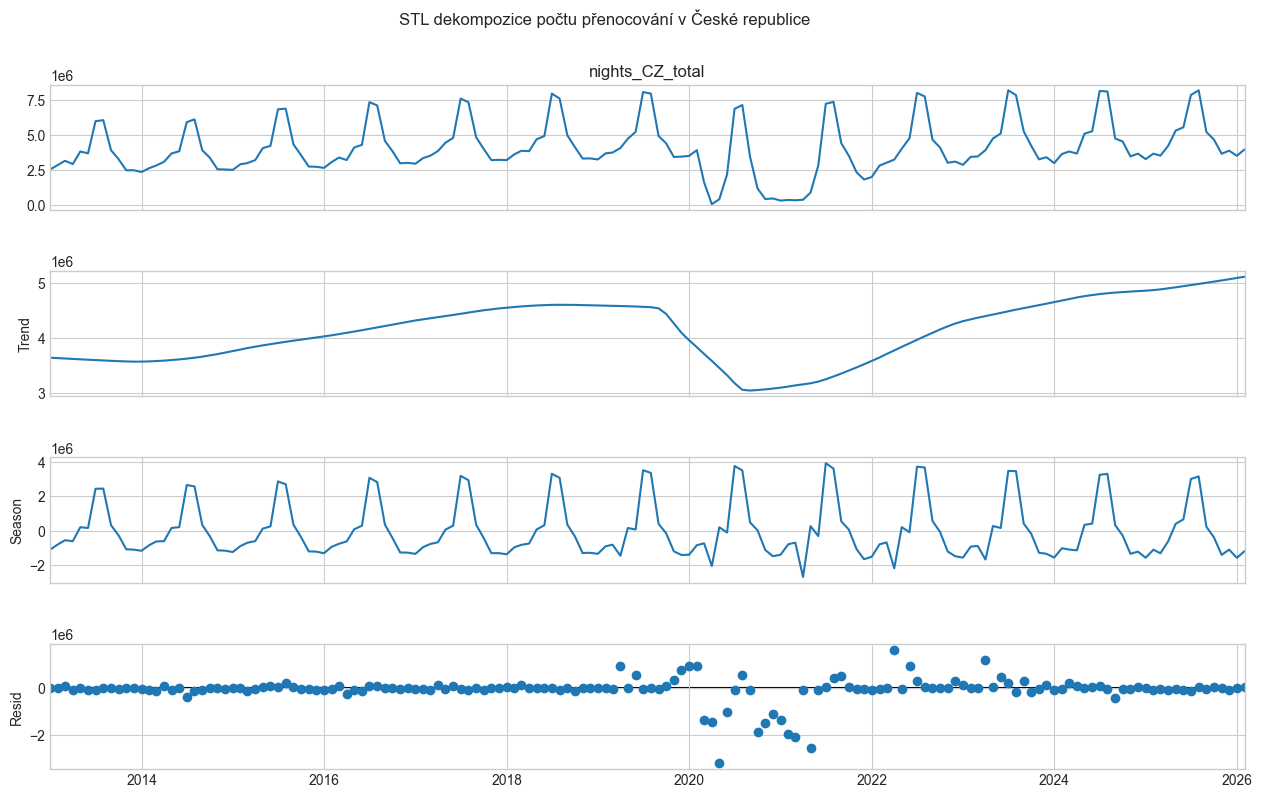

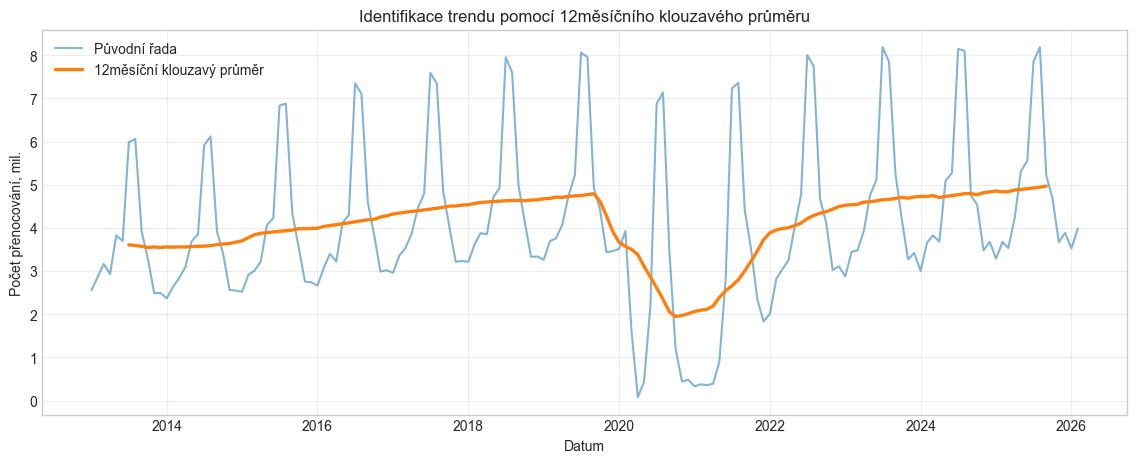

In [7]:
stl = STL(y, period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 8)
fig.suptitle("STL dekompozice počtu přenocování v České republice", y=1.02)
plt.show()

trend_ma_12 = y.rolling(window=12, center=True).mean()

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Původní řada", alpha=0.55)
plt.plot(
    trend_ma_12.index,
    trend_ma_12 / 1_000_000,
    label="12měsíční klouzavý průměr",
    linewidth=2.4,
)
plt.title("Identifikace trendu pomocí 12měsíčního klouzavého průměru")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()


**Interpretace dekompozice.** STL potvrzuje stabilní roční sezónnost. Trend roste přibližně do roku 2019, v letech 2020-2021 prudce klesá a po pandemickém období se postupně zotavuje. Reziduální složka je nejvýraznější právě během pandemie, což podporuje interpretaci COVID období jako strukturálního zlomu nebo intervence.


## 5. Regresní model: trend a sezónnost

Nyní se hledá optimální model pro samotnou řadu pomocí deterministického trendu a sezónnosti. Testují se lineární a kvadratické trendy, měsíční dummy proměnné, COVID dummy proměnná a Fourierovy členy. Cílem je najít model, který dobře popíše systematickou složku řady.


In [8]:
model_df = pd.DataFrame({"y": y})
model_df["t"] = np.arange(1, len(model_df) + 1)
model_df["t2"] = model_df["t"] ** 2
model_df["month"] = model_df.index.month.astype(str)
model_df["covid"] = (
    (model_df.index >= "2020-03-01")
    & (model_df.index <= "2021-12-01")
).astype(int)

display(model_df.head(3))
display(model_df.tail(3))


,y,t,t2,month,covid
date,,,,,
2013-01-01,"2,555,690.000",1,1,1,0
2013-02-01,"2,876,204.000",2,4,2,0
2013-03-01,"3,166,229.000",3,9,3,0


,y,t,t2,month,covid
date,,,,,
2025-12-01,"3,886,275.000",156,24336,12,0
2026-01-01,"3,526,405.000",157,24649,1,0
2026-02-01,"3,982,545.000",158,24964,2,0


V tomto bloku se odhadnou všechny regresní varianty a porovnají se podle AIC, BIC, adjustovaného \(R^2\), RMSE a Ljungova-Boxova testu reziduí. U nejlepšího Fourierova modelu se zobrazí také odhadnuté Fourierovy koeficienty.


In [9]:
model_1 = smf.ols("y ~ t + C(month)", data=model_df).fit()
model_2 = smf.ols("y ~ t + I(t**2) + C(month)", data=model_df).fit()
model_3 = smf.ols("y ~ t + I(t**2) + C(month) + covid", data=model_df).fit()


def add_fourier_terms(df, period=12, K=2):
    df = df.copy()
    t_values = df["t"].values
    for k in range(1, K + 1):
        df[f"sin_{k}"] = np.sin(2 * np.pi * k * t_values / period)
        df[f"cos_{k}"] = np.cos(2 * np.pi * k * t_values / period)
    return df


fourier_models = {}

for K in range(1, 6):
    df_k = add_fourier_terms(model_df, period=12, K=K)
    fourier_terms = " + ".join(
        [f"sin_{k} + cos_{k}" for k in range(1, K + 1)]
    )
    formula = f"y ~ t + I(t**2) + covid + {fourier_terms}"
    fit = smf.ols(formula=formula, data=df_k).fit()
    fourier_models[f"Fourier_K{K}"] = {
        "fit": fit,
        "data": df_k,
        "formula": formula,
    }

models = {
    "M1_linear_trend_month_dummies": model_1,
    "M2_quadratic_trend_month_dummies": model_2,
    "M3_quadratic_trend_month_dummies_covid": model_3,
}
models.update({name: obj["fit"] for name, obj in fourier_models.items()})

comparison_rows = []
for name, fit in models.items():
    resid = fit.resid
    lb = acorr_ljungbox(resid, lags=[12], return_df=True)
    comparison_rows.append(
        {
            "model": name,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "Adj_R2": fit.rsquared_adj,
            "RMSE": np.sqrt(np.mean(resid ** 2)),
            "Ljung_Box_pvalue_lag12": lb["lb_pvalue"].iloc[0],
        }
    )

comparison = pd.DataFrame(comparison_rows).sort_values("AIC")
display(
    comparison.round(
        {
            "AIC": 2,
            "BIC": 2,
            "Adj_R2": 4,
            "RMSE": 0,
            "Ljung_Box_pvalue_lag12": 6,
        }
    )
)

best_name = comparison.iloc[0]["model"]
best_model = models[best_name]
best_fourier_fit = fourier_models["Fourier_K5"]["fit"]

fourier_coef = pd.DataFrame(
    {
        "coefficient": best_fourier_fit.params,
        "p_value": best_fourier_fit.pvalues,
    }
)
fourier_coef = fourier_coef.loc[
    [idx for idx in fourier_coef.index if idx.startswith(("sin_", "cos_")) or idx in ["t", "I(t ** 2)", "covid"]]
]

print("Best deterministic model by AIC:", best_name)
display(fourier_coef.round({"coefficient": 2, "p_value": 6}))


,model,AIC,BIC,Adj_R2,RMSE,Ljung_Box_pvalue_lag12
7,Fourier_K5,"4,636.850","4,679.730",0.911,"522,320.000",0.000
2,M3_quadratic_trend_month_dummies_covid,"4,638.800","4,684.740",0.910,"522,242.000",0.000
6,Fourier_K4,"4,660.710","4,697.460",0.895,"570,454.000",0.000
5,Fourier_K3,"4,683.340","4,713.960",0.877,"620,611.000",0.000
4,Fourier_K2,"4,727.130","4,751.630",0.836,"721,950.000",0.000
1,M2_quadratic_trend_month_dummies,"4,800.170","4,843.050",0.749,"875,772.000",0.000
0,M1_linear_trend_month_dummies,"4,803.560","4,843.380",0.742,"890,850.000",0.000
3,Fourier_K1,"4,825.540","4,843.910",0.691,"998,260.000",0.000


Best deterministic model by AIC: Fourier_K5


,coefficient,p_value
t,"18,297.220",0.000
I(t ** 2),-63.910,0.012
covid,"-2,225,520.940",0.000
sin_1,"-1,284,266.760",0.000
cos_1,"-1,415,251.910",0.000
sin_2,"972,062.320",0.000
cos_2,"-111,554.720",0.073
sin_3,"-381,946.110",0.000
cos_3,"358,055.070",0.000
sin_4,"-32,651.510",0.596


Další blok vizualizuje nejlepší deterministický model a kontroluje autokorelaci jeho reziduí. Pokud jsou rezidua autokorelovaná, samotná regrese nestačí a je nutné přejít k modelům s časovou závislostí chyb.


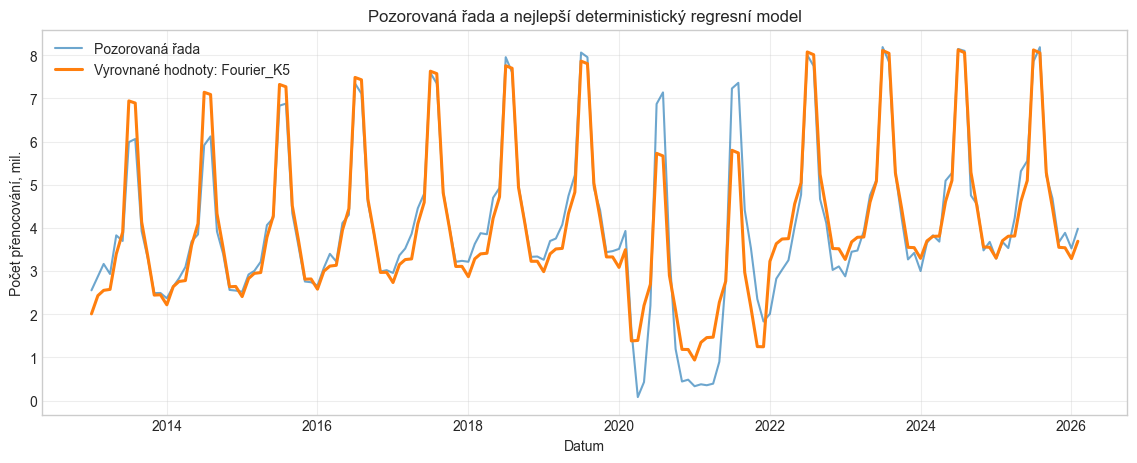

<Figure size 1000x400 with 0 Axes>

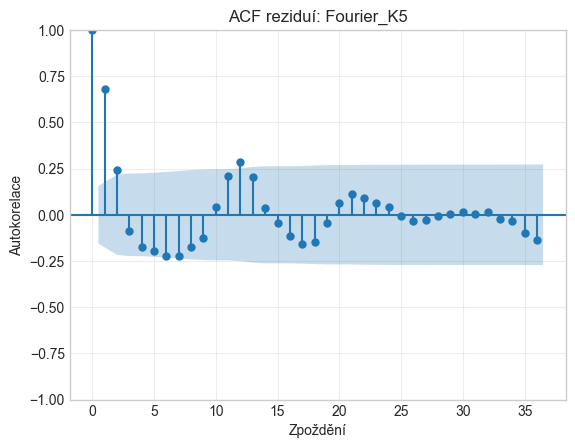

,lb_stat,lb_pvalue
12,144.248,0.000
24,168.674,0.000
36,175.138,0.000


In [10]:
plt.figure(figsize=(14, 5))
plt.plot(model_df.index, model_df["y"] / 1_000_000, label="Pozorovaná řada", alpha=0.65)
plt.plot(
    model_df.index,
    best_model.fittedvalues / 1_000_000,
    label=f"Vyrovnané hodnoty: {best_name}",
    linewidth=2.2,
)
plt.title("Pozorovaná řada a nejlepší deterministický regresní model")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(best_model.resid, lags=36)
plt.title(f"ACF reziduí: {best_name}")
plt.xlabel("Zpoždění")
plt.ylabel("Autokorelace")
plt.grid(True, alpha=0.35)
plt.show()

lb_best_deterministic = acorr_ljungbox(best_model.resid, lags=[12, 24, 36], return_df=True)
display(lb_best_deterministic.round(6))


**Interpretace regresních modelů.** Nejlepší deterministický model podle AIC je Fourierův model s pěti harmonickými složkami. Dobře popisuje trend a sezónní profil, ale Ljungův-Boxův test a ACF reziduí ukazují výraznou autokorelaci. Model tedy splňuje požadavek na funkční popis trendu a sezónnosti, ale není dostačující jako finální model časové závislosti.


## 6. SARIMA model pro samotnou řadu

SARIMA model se používá proto, aby zachytil autokorelaci a sezónní závislosti přímo v hlavní řadě. Před odhadem se zobrazí ACF/PACF původní a sezónně diferencované řady, což pomáhá ověřit charakter časové závislosti.


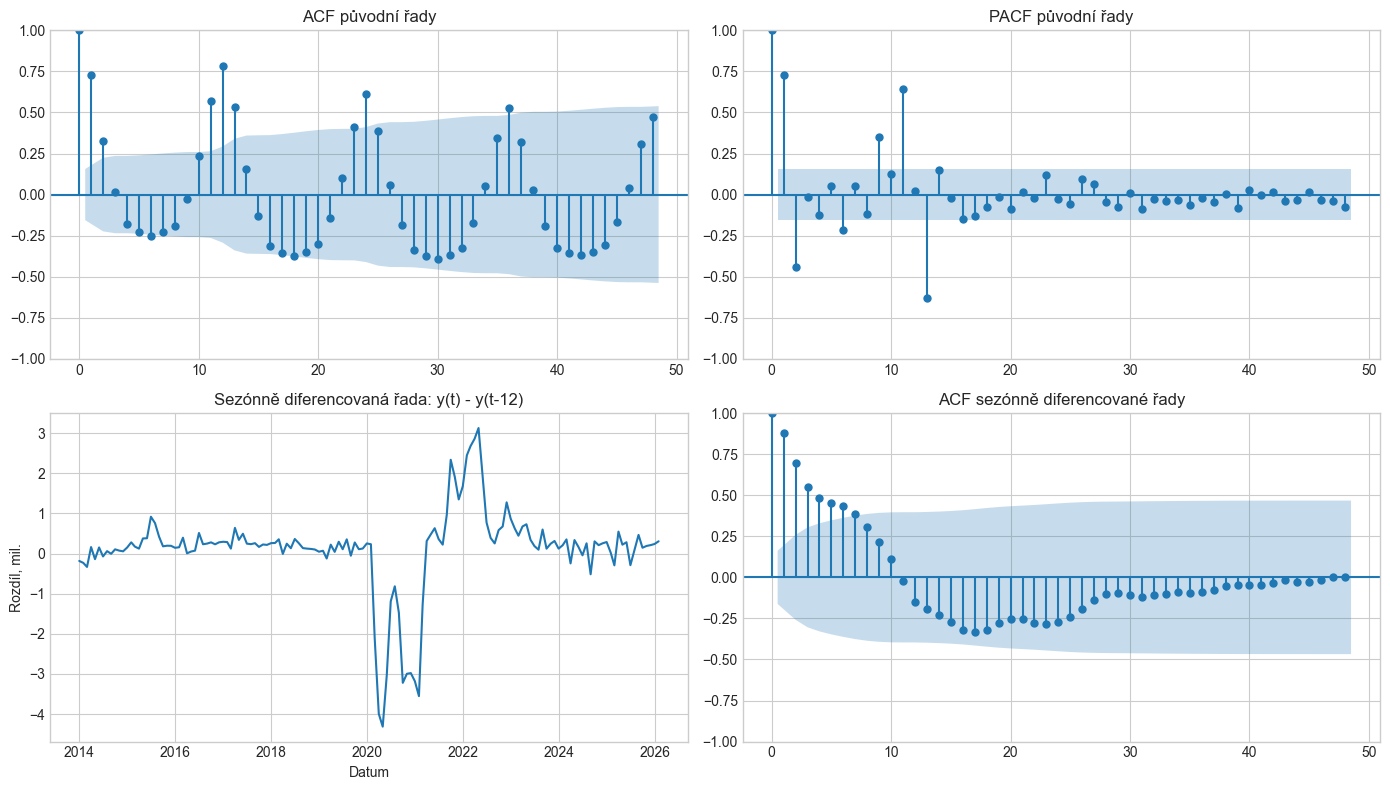

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(y, lags=48, ax=axes[0, 0])
axes[0, 0].set_title("ACF původní řady")
plot_pacf(y, lags=48, method="ywm", ax=axes[0, 1])
axes[0, 1].set_title("PACF původní řady")

y_seasonal_diff = y.diff(12).dropna()
axes[1, 0].plot(y_seasonal_diff.index, y_seasonal_diff / 1_000_000)
axes[1, 0].set_title("Sezónně diferencovaná řada: y(t) - y(t-12)")
axes[1, 0].set_xlabel("Datum")
axes[1, 0].set_ylabel("Rozdíl, mil.")
plot_acf(y_seasonal_diff, lags=48, ax=axes[1, 1])
axes[1, 1].set_title("ACF sezónně diferencované řady")

plt.tight_layout()
plt.show()


Následující blok použije `auto_arima` pro výběr řádu SARIMA modelu a poté vybraný model znovu odhadne ve `statsmodels`. Finální srovnávací tabulky používají AIC/BIC ze `statsmodels`, aby byly hodnoty pro SARIMA a SARIMAX počítány stejným nástrojem.


In [12]:
sarima_auto = pm.auto_arima(
    y,
    seasonal=True,
    m=12,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=None,
    D=None,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    information_criterion="aic",
)

order = sarima_auto.order
seasonal_order = sarima_auto.seasonal_order

sarima_model = SARIMAX(
    y,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)

sarima_selection = pd.DataFrame(
    {
        "value": [
            str(order),
            str(seasonal_order),
            sarima_auto.aic(),
            sarima_fit.aic,
            sarima_fit.bic,
        ]
    },
    index=[
        "selected_order",
        "selected_seasonal_order",
        "pmdarima_auto_arima_AIC",
        "statsmodels_refit_AIC",
        "statsmodels_refit_BIC",
    ],
)
display(sarima_selection)

sarima_params = pd.DataFrame(
    {
        "coefficient": sarima_fit.params,
        "std_error": sarima_fit.bse,
        "p_value": sarima_fit.pvalues,
    }
)
display(sarima_params.round({"coefficient": 3, "std_error": 3, "p_value": 6}))


,value
selected_order,"(2, 0, 0)"
selected_seasonal_order,"(0, 0, 2, 12)"
pmdarima_auto_arima_AIC,"4,771.066"
statsmodels_refit_AIC,"4,038.246"
statsmodels_refit_BIC,"4,052.698"


,coefficient,std_error,p_value
ar.L1,1.186,0.290,0.000
ar.L2,-0.257,0.274,0.349
ma.S.L12,0.766,0.172,0.000
ma.S.L24,0.612,0.168,0.000
sigma2,"1,626,121,239,653.205",0.000,0.000


Tento blok porovná pozorované a vyrovnané hodnoty SARIMA modelu a poté zkontroluje rezidua pomocí ACF a Ljungova-Boxova testu. Prvních 24 reziduí se v diagnostice vynechává kvůli počátečnímu náběhu stavového modelu.


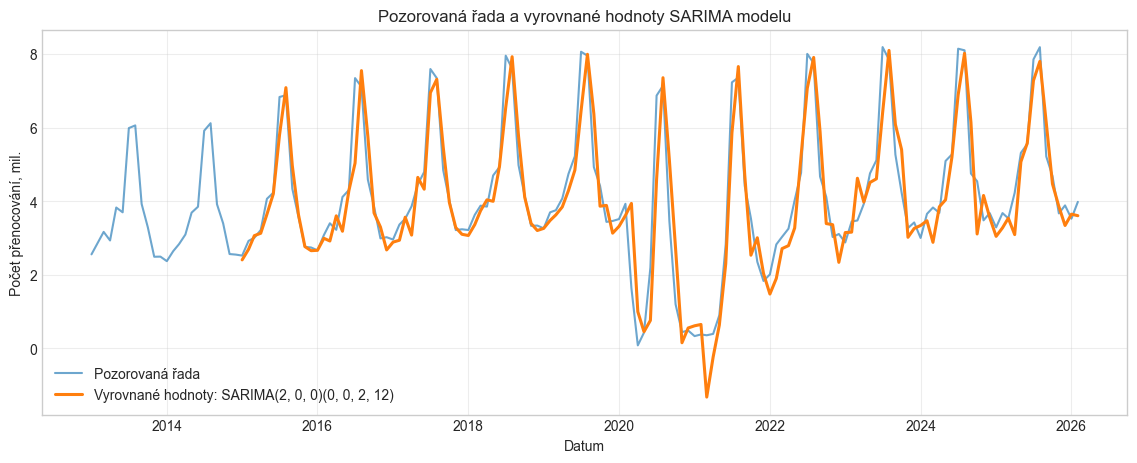

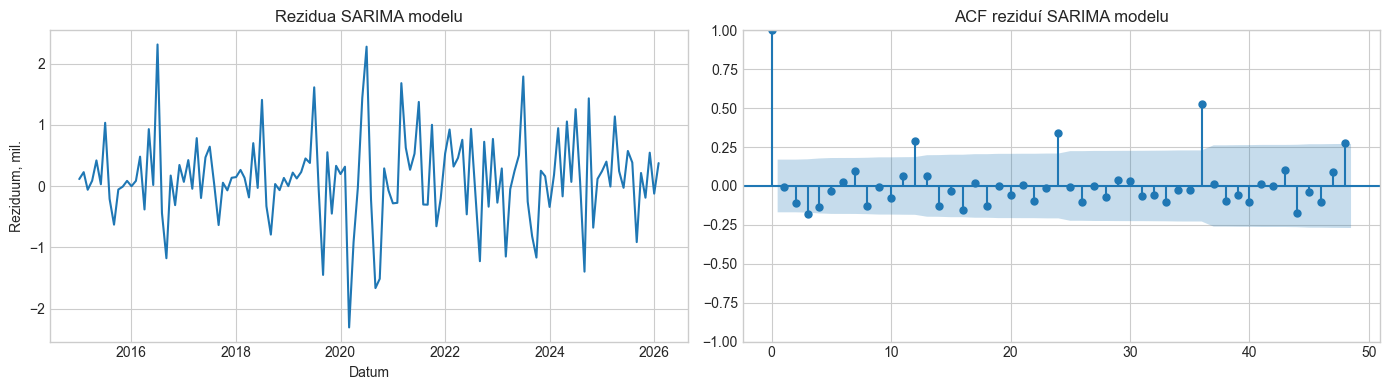

,lb_stat,lb_pvalue
12,26.276,0.010
24,57.366,0.000
36,115.797,0.000


In [13]:
sarima_label = f"SARIMA{order}{seasonal_order}"
burn = 24

sarima_fitted_trimmed = sarima_fit.fittedvalues.copy()
sarima_fitted_trimmed.iloc[:burn] = np.nan

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Pozorovaná řada", alpha=0.65)
plt.plot(
    sarima_fitted_trimmed.index,
    sarima_fitted_trimmed / 1_000_000,
    label=f"Vyrovnané hodnoty: {sarima_label}",
    linewidth=2.2,
)
plt.title("Pozorovaná řada a vyrovnané hodnoty SARIMA modelu")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

sarima_resid_trimmed = sarima_fit.resid.iloc[burn:].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(sarima_resid_trimmed.index, sarima_resid_trimmed / 1_000_000)
axes[0].set_title("Rezidua SARIMA modelu")
axes[0].set_xlabel("Datum")
axes[0].set_ylabel("Reziduum, mil.")
plot_acf(sarima_resid_trimmed, lags=48, ax=axes[1])
axes[1].set_title("ACF reziduí SARIMA modelu")
plt.tight_layout()
plt.show()

lb_sarima_trimmed = acorr_ljungbox(
    sarima_resid_trimmed,
    lags=[12, 24, 36],
    return_df=True,
)
display(lb_sarima_trimmed.round(6))


**Interpretace SARIMA modelu.** Automatický výběr volí sezónní model s periodou 12. SARIMA lépe zachycuje časovou závislost než čistě deterministická regrese, ale reziduální autokorelace stále zůstává významná, zejména na delších sezónních zpožděních. Samotná minulost hlavní řady tedy nestačí k plnému vysvětlení variability.


## 7. Kroskorelace s dalšími časovými řadami

Kroskorelace se používá k nalezení řad, které mohou souviset s hlavní řadou, a k určení případného zpoždění závislosti. Protože turistické řady sdílejí trend a sezónnost, nejprve se z každé řady odstraní deterministické složky a kroskorelace se počítá z reziduí.


In [14]:
def deterministic_residuals(series):
    df = pd.DataFrame({"value": series}).dropna()
    df["t"] = np.arange(1, len(df) + 1)
    df["month"] = df.index.month.astype(str)
    df["covid"] = (
        (df.index >= "2020-03-01")
        & (df.index <= "2021-12-01")
    ).astype(int)

    fit = smf.ols(
        "value ~ t + I(t**2) + C(month) + covid",
        data=df,
    ).fit()
    return fit.resid


def lagged_cross_correlation(y_resid, x_resid, max_lag=24):
    result = []
    common = pd.concat([y_resid, x_resid], axis=1).dropna()
    yv = common.iloc[:, 0]
    xv = common.iloc[:, 1]

    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            y_aligned = yv.iloc[lag:]
            x_aligned = xv.iloc[:-lag]
        elif lag < 0:
            y_aligned = yv.iloc[:lag]
            x_aligned = xv.iloc[-lag:]
        else:
            y_aligned = yv
            x_aligned = xv

        corr = np.corrcoef(y_aligned, x_aligned)[0, 1]
        result.append(
            {
                "lag": lag,
                "correlation": corr,
                "abs_correlation": abs(corr),
            }
        )
    return pd.DataFrame(result)


external_candidates = [
    "arrivals_CZ_total",
    "arrivals_AT_total",
    "arrivals_DE_total",
    "arrivals_SK_total",
    "arrivals_PL_total",
    "nights_AT_total",
    "nights_DE_total",
    "nights_SK_total",
    "nights_PL_total",
]

y_resid = deterministic_residuals(data_clean["nights_CZ_total"])
ccf_summary = []

for col in external_candidates:
    x_resid = deterministic_residuals(data_clean[col])
    ccf_df = lagged_cross_correlation(y_resid, x_resid, max_lag=24)
    best_row = ccf_df.loc[ccf_df["abs_correlation"].idxmax()]
    ccf_summary.append(
        {
            "series": col,
            "best_lag": int(best_row["lag"]),
            "correlation": best_row["correlation"],
            "abs_correlation": best_row["abs_correlation"],
        }
    )

ccf_summary = pd.DataFrame(ccf_summary).sort_values(
    "abs_correlation",
    ascending=False,
)
display(ccf_summary.round({"correlation": 3, "abs_correlation": 3}))


,series,best_lag,correlation,abs_correlation
0,arrivals_CZ_total,0,0.989,0.989
2,arrivals_DE_total,0,0.900,0.900
4,arrivals_PL_total,0,0.891,0.891
6,nights_DE_total,0,0.878,0.878
3,arrivals_SK_total,0,0.873,0.873
8,nights_PL_total,0,0.870,0.870
7,nights_SK_total,0,0.857,0.857
1,arrivals_AT_total,0,0.850,0.850
5,nights_AT_total,0,0.735,0.735


Následující grafy zobrazují kroskorelační funkce pro nejsilněji související řady. Kladné zpoždění znamená, že externí řada předchází hlavní řadu o daný počet měsíců.


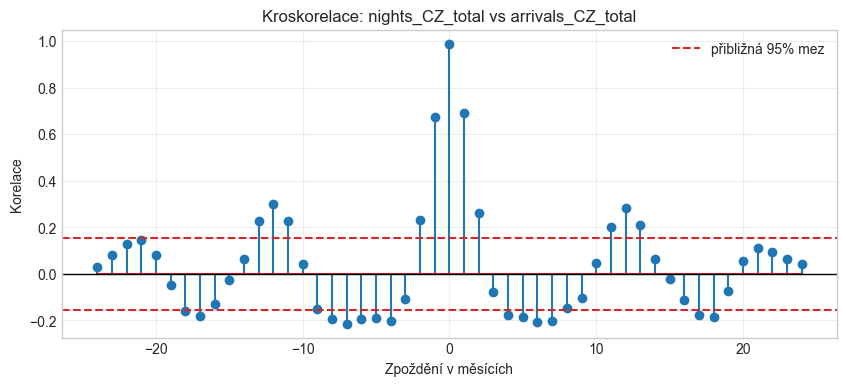

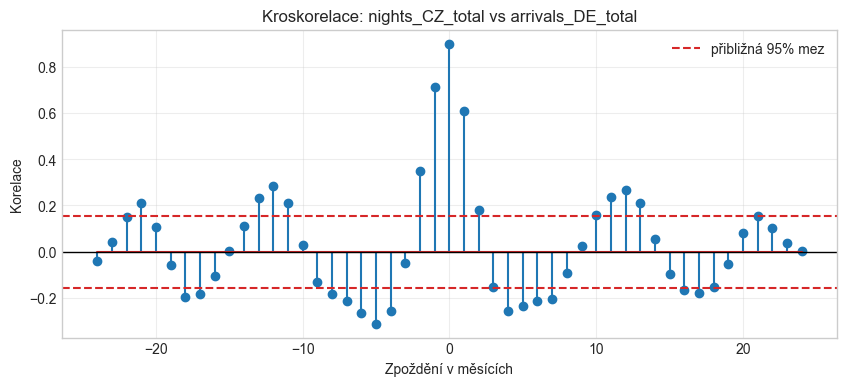

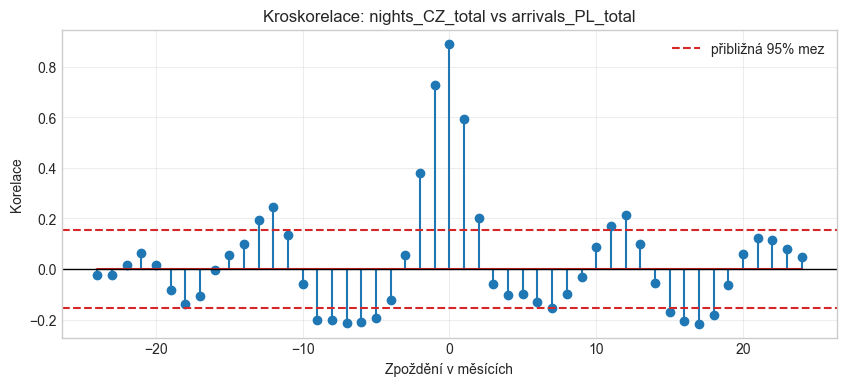

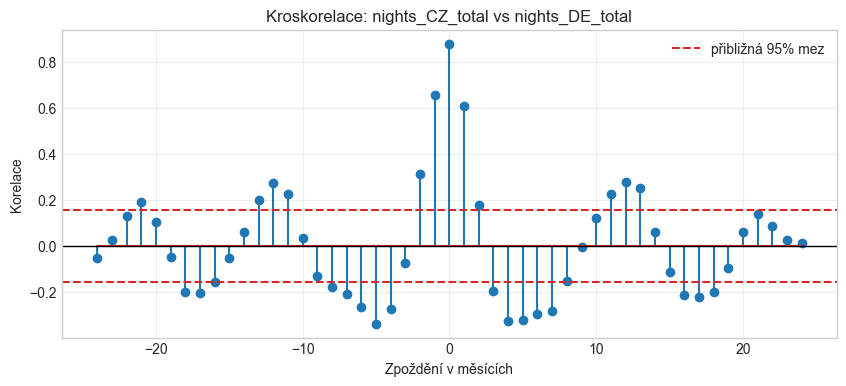

In [15]:
top_series = ccf_summary.head(4)["series"].tolist()

for col in top_series:
    x_resid = deterministic_residuals(data_clean[col])
    ccf_df = lagged_cross_correlation(y_resid, x_resid, max_lag=24)

    plt.figure(figsize=(10, 4))
    plt.stem(ccf_df["lag"], ccf_df["correlation"])
    plt.axhline(0, linewidth=1, color="black")

    n = len(y_resid.dropna())
    bound = 1.96 / np.sqrt(n)
    plt.axhline(bound, linestyle="--", color="tab:red", label="přibližná 95% mez")
    plt.axhline(-bound, linestyle="--", color="tab:red")

    plt.title(f"Kroskorelace: nights_CZ_total vs {col}")
    plt.xlabel("Zpoždění v měsících")
    plt.ylabel("Korelace")
    plt.legend()
    plt.grid(True, alpha=0.35)
    plt.show()


**Interpretace kroskorelace.** Nejsilnější vztahy jsou převážně současné, tedy při zpoždění 0. To znamená, že vysoká turistická aktivita v souvisejících řadách se objevuje ve stejných měsících jako vysoký počet přenocování v České republice. Výsledky podporují použití externích regresorů v SARIMAX modelu, nikoliv výrazně zpožděných verzí těchto řad.


## 8. SARIMAX s externími regresory

V této části se kombinuje závislost na externích turistických řadách s řešením autokorelace pomocí SARIMA struktury chyb. Externí proměnné jsou standardizovány kvůli numerické stabilitě a porovnává se několik sad regresorů.


In [16]:
def fit_sarimax_with_exog(y, exog_cols, order=(2, 0, 0), seasonal_order=(0, 0, 2, 12)):
    df = pd.concat([y, data_clean[exog_cols]], axis=1).dropna()
    y_model = df.iloc[:, 0]
    X = df[exog_cols]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        index=X.index,
        columns=exog_cols,
    )

    model = SARIMAX(
        y_model,
        exog=X_scaled,
        order=order,
        seasonal_order=seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)

    return {
        "fit": fit,
        "y": y_model,
        "X_scaled": X_scaled,
        "scaler": scaler,
        "exog_cols": exog_cols,
    }


exog_model_specs = {
    "A_CZ_arrivals": ["arrivals_CZ_total"],
    "B_CZ_DE_arrivals": ["arrivals_CZ_total", "arrivals_DE_total"],
    "C_CZ_DE_PL_arrivals": ["arrivals_CZ_total", "arrivals_DE_total", "arrivals_PL_total"],
    "D_external_arrivals_only": ["arrivals_DE_total", "arrivals_PL_total", "arrivals_SK_total"],
    "E_external_nights_only": ["nights_DE_total", "nights_PL_total", "nights_SK_total"],
}

sarimax_exog_results = {}
for name, cols in exog_model_specs.items():
    sarimax_exog_results[name] = fit_sarimax_with_exog(
        y=y,
        exog_cols=cols,
        order=(2, 0, 0),
        seasonal_order=(0, 0, 2, 12),
    )

sarimax_comparison_rows = []
for name, obj in sarimax_exog_results.items():
    fit = obj["fit"]
    resid_trimmed = fit.resid.iloc[24:].dropna()
    lb = acorr_ljungbox(resid_trimmed, lags=[12, 24, 36], return_df=True)
    sarimax_comparison_rows.append(
        {
            "model": name,
            "exog": ", ".join(obj["exog_cols"]),
            "AIC": fit.aic,
            "BIC": fit.bic,
            "RMSE_trimmed": np.sqrt(np.mean(resid_trimmed ** 2)),
            "LB_pvalue_lag12": lb.loc[12, "lb_pvalue"],
            "LB_pvalue_lag24": lb.loc[24, "lb_pvalue"],
            "LB_pvalue_lag36": lb.loc[36, "lb_pvalue"],
        }
    )

sarimax_comparison = pd.DataFrame(sarimax_comparison_rows).sort_values("AIC")
display(
    sarimax_comparison.round(
        {
            "AIC": 2,
            "BIC": 2,
            "RMSE_trimmed": 0,
            "LB_pvalue_lag12": 6,
            "LB_pvalue_lag24": 6,
            "LB_pvalue_lag36": 6,
        }
    )
)

best_sarimax_name = sarimax_comparison.iloc[0]["model"]
best_obj = sarimax_exog_results[best_sarimax_name]
best_fit = best_obj["fit"]
best_y = best_obj["y"]

print("Best SARIMAX model by AIC:", best_sarimax_name)
print("External regressors:", ", ".join(best_obj["exog_cols"]))


,model,exog,AIC,BIC,RMSE_trimmed,LB_pvalue_lag12,LB_pvalue_lag24,LB_pvalue_lag36
4,E_external_nights_only,"nights_DE_total, nights_PL_total, nights_SK_total","3,663.140","3,689.150","206,263.000",0.065,0.006,0.000
1,B_CZ_DE_arrivals,"arrivals_CZ_total, arrivals_DE_total","3,667.630","3,690.750","196,728.000",0.016,0.000,0.000
2,C_CZ_DE_PL_arrivals,"arrivals_CZ_total, arrivals_DE_total, arrivals...","3,675.610","3,701.620","219,981.000",0.238,0.040,0.004
0,A_CZ_arrivals,arrivals_CZ_total,"3,703.230","3,723.460","211,489.000",0.000,0.000,0.000
3,D_external_arrivals_only,"arrivals_DE_total, arrivals_PL_total, arrivals...","3,850.480","3,876.500","387,000.000",0.000,0.000,0.000


Best SARIMAX model by AIC: E_external_nights_only
External regressors: nights_DE_total, nights_PL_total, nights_SK_total


Tento blok zobrazí koeficienty nejlepšího SARIMAX modelu, jeho vyrovnané hodnoty a diagnostiku reziduí. Stejně jako u SARIMA se při diagnostice vynechává prvních 24 reziduí.


,coefficient,std_error,p_value
intercept,"2,845,562.343","18,624.561",0.000
nights_DE_total,"302,814.577","132,987.240",0.023
nights_PL_total,"813,806.755","157,987.177",0.000
nights_SK_total,"730,580.446","94,630.977",0.000
ar.L1,0.293,0.117,0.012
ar.L2,-0.003,0.111,0.980
ma.S.L12,0.367,0.156,0.018
ma.S.L24,0.465,0.136,0.001
sigma2,"67,532,197,767.563",0.440,0.000


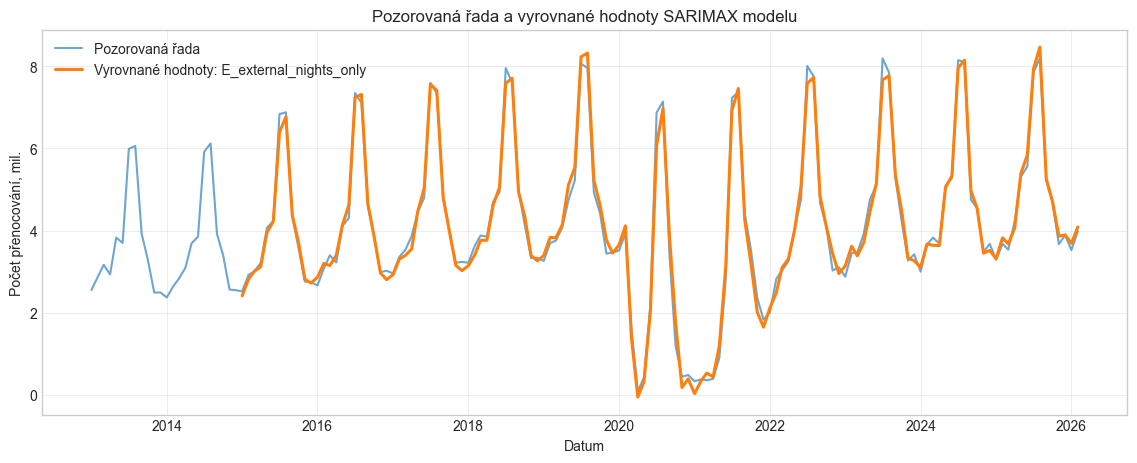

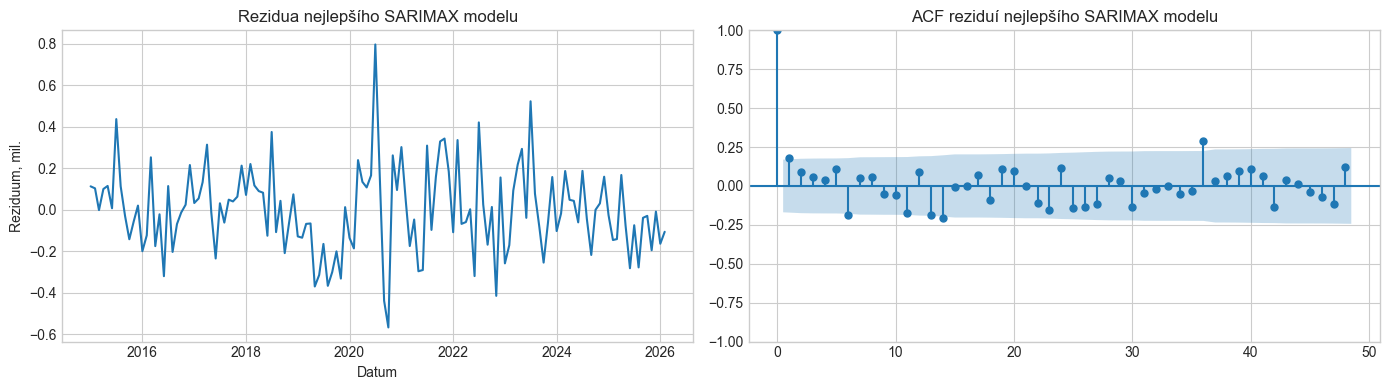

,lb_stat,lb_pvalue
12,20.117,0.065
24,44.896,0.006
36,73.973,0.000


In [17]:
sarimax_params = pd.DataFrame(
    {
        "coefficient": best_fit.params,
        "std_error": best_fit.bse,
        "p_value": best_fit.pvalues,
    }
)
display(sarimax_params.round({"coefficient": 3, "std_error": 3, "p_value": 6}))

fitted = best_fit.fittedvalues.copy()
fitted.iloc[:24] = np.nan

plt.figure(figsize=(14, 5))
plt.plot(best_y.index, best_y / 1_000_000, label="Pozorovaná řada", alpha=0.65)
plt.plot(
    fitted.index,
    fitted / 1_000_000,
    label=f"Vyrovnané hodnoty: {best_sarimax_name}",
    linewidth=2.2,
)
plt.title("Pozorovaná řada a vyrovnané hodnoty SARIMAX modelu")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

best_resid = best_fit.resid.iloc[24:].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(best_resid.index, best_resid / 1_000_000)
axes[0].set_title("Rezidua nejlepšího SARIMAX modelu")
axes[0].set_xlabel("Datum")
axes[0].set_ylabel("Reziduum, mil.")
plot_acf(best_resid, lags=48, ax=axes[1])
axes[1].set_title("ACF reziduí nejlepšího SARIMAX modelu")
plt.tight_layout()
plt.show()

lb_best_sarimax = acorr_ljungbox(best_resid, lags=[12, 24, 36], return_df=True)
display(lb_best_sarimax.round(6))


**Interpretace SARIMAX modelu.** Nejlepší varianta používá externí řady přenocování v Německu, Polsku a na Slovensku. Oproti čistému SARIMA modelu výrazně zlepšuje fit i diagnostiku reziduí. Na zpoždění 12 je autokorelace podstatně slabší, ale na zpožděních 24 a 36 zůstává statisticky významná; finální model tedy není dokonalý, pouze nejlepší z testovaných variant.


## 9. Kontrola periody, diagnostika a predikce

### 9.1 Kontrola periody pomocí periodogramu

Periodogram se používá jako nezávislá kontrola sezónní periody. U měsíčních turistických dat očekáváme dominantní frekvenci odpovídající přibližně 12 měsícům.


,frequency,period_months,power
12,0.082,12.150,"252,936,742,808,859.000"
25,0.165,6.080,"58,705,420,356,280.000"
26,0.171,5.850,"24,843,721,192,846.000"
13,0.089,11.290,"15,701,101,009,549.000"
3,0.025,39.500,"14,439,747,786,953.000"
14,0.095,10.530,"9,868,260,690,331.000"
39,0.253,3.950,"8,948,181,906,860.000"
2,0.019,52.670,"8,744,860,918,667.000"
38,0.247,4.050,"8,293,845,110,797.000"
52,0.335,2.980,"7,501,857,945,902.000"


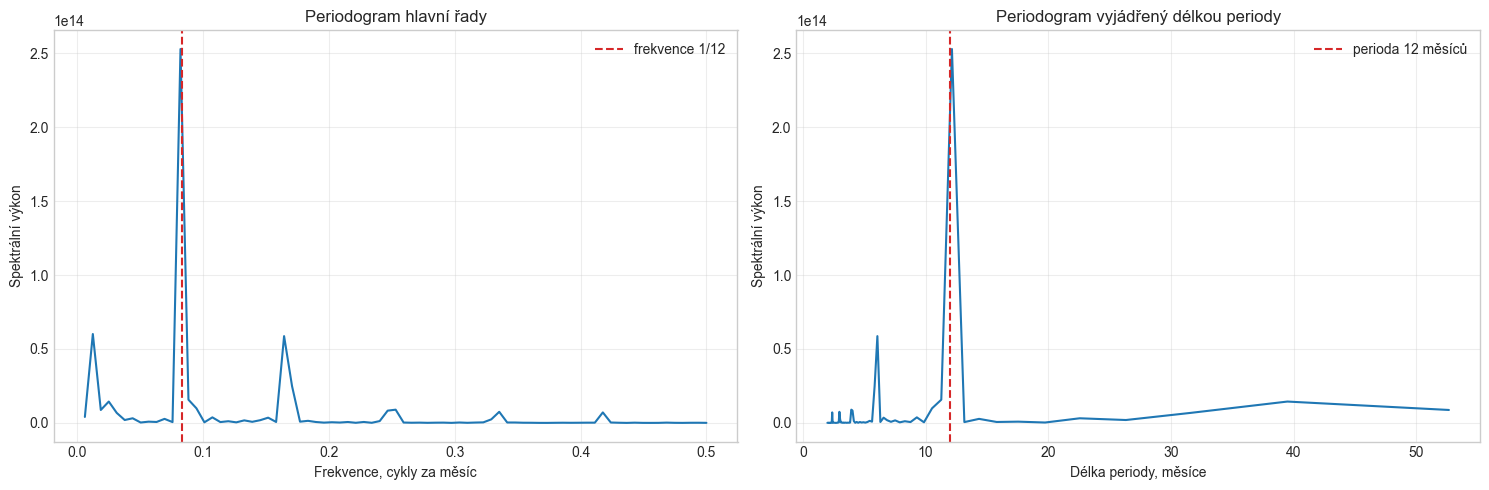

In [18]:
y_values = y.values.astype(float)
y_centered = y_values - np.mean(y_values)

freqs, power = periodogram(y_centered, fs=1)
freqs_nonzero = freqs[1:]
power_nonzero = power[1:]
periods = 1 / freqs_nonzero

periodogram_df = pd.DataFrame(
    {
        "frequency": freqs_nonzero,
        "period_months": periods,
        "power": power_nonzero,
    }
).sort_values("power", ascending=False)

top_periods = periodogram_df[
    (periodogram_df["period_months"] >= 2)
    & (periodogram_df["period_months"] <= 60)
].head(10)

display(top_periods.round({"frequency": 4, "period_months": 2, "power": 0}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(freqs_nonzero, power_nonzero)
axes[0].axvline(1 / 12, linestyle="--", color="tab:red", label="frekvence 1/12")
axes[0].set_title("Periodogram hlavní řady")
axes[0].set_xlabel("Frekvence, cykly za měsíc")
axes[0].set_ylabel("Spektrální výkon")
axes[0].legend()
axes[0].grid(True, alpha=0.35)

periodogram_plot_df = periodogram_df[
    (periodogram_df["period_months"] >= 2)
    & (periodogram_df["period_months"] <= 60)
].sort_values("period_months")
axes[1].plot(periodogram_plot_df["period_months"], periodogram_plot_df["power"])
axes[1].axvline(12, linestyle="--", color="tab:red", label="perioda 12 měsíců")
axes[1].set_title("Periodogram vyjádřený délkou periody")
axes[1].set_xlabel("Délka periody, měsíce")
axes[1].set_ylabel("Spektrální výkon")
axes[1].legend()
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()


**Interpretace periodogramu.** Nejsilnější spektrální maximum leží přibližně u periody 12 měsíců. Další lokální maxima okolo 6, 4 a 3 měsíců lze chápat jako harmonické složky roční sezónnosti. Periodogram tedy podporuje volbu sezónní periody \(s = 12\) v modelech SARIMA a SARIMAX.


### 9.2 Souhrnná diagnostika reziduí

Zde se porovnají rezidua tří hlavních kandidátů: nejlepší Fourierovy regrese, SARIMA modelu a nejlepšího SARIMAX modelu. Hlavním kritériem diagnostiky je nezávislost reziduí podle ACF a Ljungova-Boxova testu.


In [19]:
diagnostic_rows = []

fourier_resid = best_fourier_fit.resid
lb_fourier = acorr_ljungbox(fourier_resid, lags=[12, 24, 36], return_df=True)
diagnostic_rows.append(
    {
        "model": "Fourier_K5 regression",
        "AIC_source": "statsmodels OLS",
        "AIC": best_fourier_fit.aic,
        "BIC": best_fourier_fit.bic,
        "RMSE": np.sqrt(np.mean(fourier_resid ** 2)),
        "LB_pvalue_lag12": lb_fourier.loc[12, "lb_pvalue"],
        "LB_pvalue_lag24": lb_fourier.loc[24, "lb_pvalue"],
        "LB_pvalue_lag36": lb_fourier.loc[36, "lb_pvalue"],
    }
)

sarima_resid_trimmed = sarima_fit.resid.iloc[24:].dropna()
lb_sarima = acorr_ljungbox(sarima_resid_trimmed, lags=[12, 24, 36], return_df=True)
diagnostic_rows.append(
    {
        "model": sarima_label,
        "AIC_source": "statsmodels SARIMAX refit",
        "AIC": sarima_fit.aic,
        "BIC": sarima_fit.bic,
        "RMSE": np.sqrt(np.mean(sarima_resid_trimmed ** 2)),
        "LB_pvalue_lag12": lb_sarima.loc[12, "lb_pvalue"],
        "LB_pvalue_lag24": lb_sarima.loc[24, "lb_pvalue"],
        "LB_pvalue_lag36": lb_sarima.loc[36, "lb_pvalue"],
    }
)

sarimax_resid_trimmed = best_fit.resid.iloc[24:].dropna()
lb_sarimax = acorr_ljungbox(sarimax_resid_trimmed, lags=[12, 24, 36], return_df=True)
diagnostic_rows.append(
    {
        "model": f"SARIMAX: {best_sarimax_name}",
        "AIC_source": "statsmodels SARIMAX",
        "AIC": best_fit.aic,
        "BIC": best_fit.bic,
        "RMSE": np.sqrt(np.mean(sarimax_resid_trimmed ** 2)),
        "LB_pvalue_lag12": lb_sarimax.loc[12, "lb_pvalue"],
        "LB_pvalue_lag24": lb_sarimax.loc[24, "lb_pvalue"],
        "LB_pvalue_lag36": lb_sarimax.loc[36, "lb_pvalue"],
    }
)

diagnostic_summary = pd.DataFrame(diagnostic_rows)
display(
    diagnostic_summary.round(
        {
            "AIC": 2,
            "BIC": 2,
            "RMSE": 0,
            "LB_pvalue_lag12": 6,
            "LB_pvalue_lag24": 6,
            "LB_pvalue_lag36": 6,
        }
    )
)


,model,AIC_source,AIC,BIC,RMSE,LB_pvalue_lag12,LB_pvalue_lag24,LB_pvalue_lag36
0,Fourier_K5 regression,statsmodels OLS,"4,636.850","4,679.730","522,320.000",0.000,0.000,0.000
1,"SARIMA(2, 0, 0)(0, 0, 2, 12)",statsmodels SARIMAX refit,"4,038.250","4,052.700","732,597.000",0.010,0.000,0.000
2,SARIMAX: E_external_nights_only,statsmodels SARIMAX,"3,663.140","3,689.150","206,263.000",0.065,0.006,0.000


**Interpretace diagnostiky.** Fourierova regrese má dobrý deterministický popis sezónnosti, ale rezidua jsou silně autokorelovaná. SARIMA autokorelaci částečně řeší, ale stále ji neodstraňuje dostatečně. SARIMAX má nejlepší kombinaci AIC/BIC, RMSE a diagnostiky reziduí, i když autokorelace na zpožděních 24 a 36 zůstává. AIC je navíc nutné interpretovat opatrně při porovnávání různých modelových rodin; v tabulce je uveden zdroj výpočtu.


### 9.3 Predikce 10 budoucích pozorování

Predikce se provede pro tři vhodné modely: Fourierovu regresi, SARIMA a SARIMAX. Horizont začíná automaticky měsíc po posledním skutečném pozorování, aby nedošlo k ručnímu posunu začátku forecastu.


In [20]:
future_steps = 10
future_index = pd.date_range(
    start=y.index.max() + pd.offsets.MonthBegin(1),
    periods=future_steps,
    freq="MS",
)

forecast_horizon_summary = pd.DataFrame(
    {
        "date": [
            y.index.max().strftime("%Y-%m-%d"),
            future_index.min().strftime("%Y-%m-%d"),
            future_index.max().strftime("%Y-%m-%d"),
        ]
    },
    index=["last_observed_month", "forecast_start", "forecast_end"],
)
display(forecast_horizon_summary)


def forecast_table_millions(forecast, lower_col, upper_col):
    out = pd.DataFrame(
        {
            "mean_millions": forecast["mean"] / 1_000_000,
            "lower_millions": forecast[lower_col] / 1_000_000,
            "upper_millions": forecast[upper_col] / 1_000_000,
        },
        index=forecast.index,
    )
    return out.round(3)


,date
last_observed_month,2026-02-01
forecast_start,2026-03-01
forecast_end,2026-12-01


Nejprve se predikuje pomocí nejlepší Fourierovy regrese. Pro budoucí měsíce se vytvoří trendové proměnné, COVID dummy se nastaví na nulu a doplní se Fourierovy členy.


,mean_millions,lower_millions,upper_millions
2026-03-01,3.794,2.647,4.941
2026-04-01,3.796,2.647,4.945
2026-05-01,4.595,3.445,5.745
2026-06-01,5.078,3.926,6.230
2026-07-01,8.103,6.949,9.256
2026-08-01,8.033,6.878,9.188
2026-09-01,5.259,4.102,6.415
2026-10-01,4.438,3.279,5.597
2026-11-01,3.524,2.364,4.684
2026-12-01,3.512,2.350,4.675


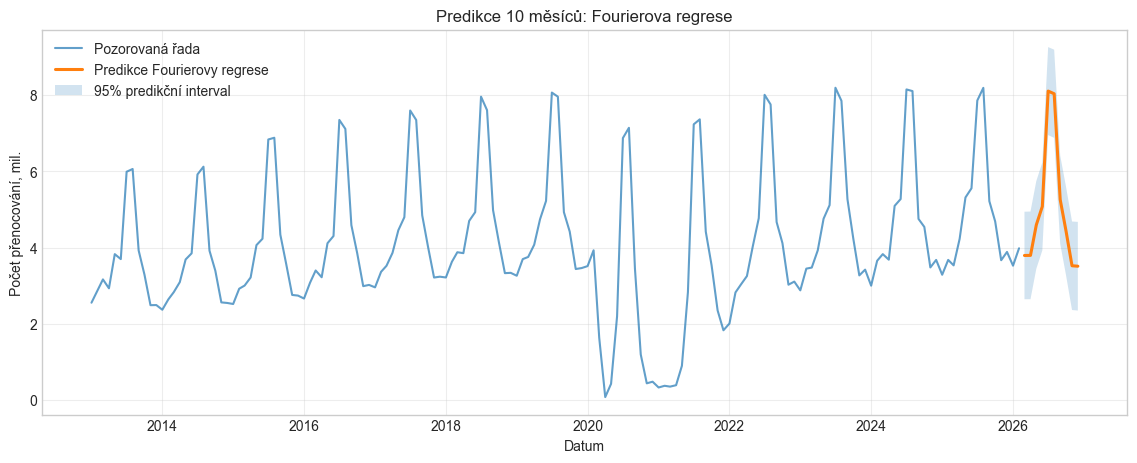

In [21]:
future_df = pd.DataFrame(index=future_index)
future_df["y"] = np.nan

last_t = model_df["t"].iloc[-1]
future_df["t"] = np.arange(last_t + 1, last_t + future_steps + 1)
future_df["t2"] = future_df["t"] ** 2
future_df["month"] = future_df.index.month.astype(str)
future_df["covid"] = 0
future_df = add_fourier_terms(future_df, period=12, K=5)

fourier_pred = best_fourier_fit.get_prediction(future_df)
fourier_forecast = fourier_pred.summary_frame(alpha=0.05)
fourier_forecast.index = future_index

display(forecast_table_millions(fourier_forecast, "obs_ci_lower", "obs_ci_upper"))

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Pozorovaná řada", alpha=0.7)
plt.plot(
    fourier_forecast.index,
    fourier_forecast["mean"] / 1_000_000,
    label="Predikce Fourierovy regrese",
    linewidth=2.2,
)
plt.fill_between(
    fourier_forecast.index,
    fourier_forecast["obs_ci_lower"] / 1_000_000,
    fourier_forecast["obs_ci_upper"] / 1_000_000,
    alpha=0.2,
    label="95% predikční interval",
)
plt.title("Predikce 10 měsíců: Fourierova regrese")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()


Druhou predikci poskytne čistý SARIMA model. Zde nejsou potřeba externí proměnné; intervaly vycházejí z nejistoty stavového modelu.


,mean_millions,lower_millions,upper_millions
2026-03-01,4.393,1.894,6.893
2026-04-01,4.959,1.081,8.837
2026-05-01,5.588,0.760,10.415
2026-06-01,5.378,-0.129,10.885
2026-07-01,6.154,0.145,12.164
2026-08-01,6.265,-0.125,12.656
2026-09-01,4.302,-2.383,10.986
2026-10-01,4.536,-2.379,11.451
2026-11-01,3.719,-3.377,10.816
2026-12-01,3.739,-3.502,10.979


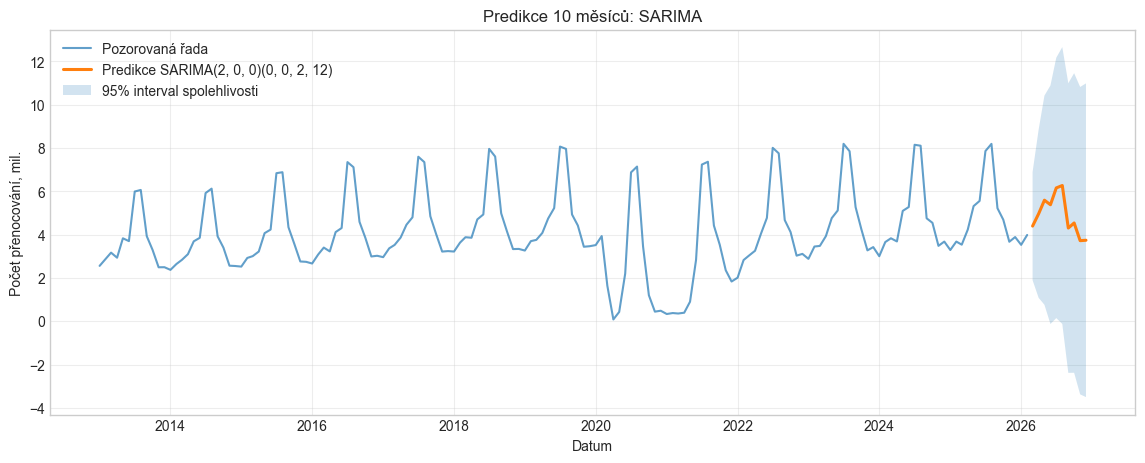

In [22]:
sarima_forecast_res = sarima_fit.get_forecast(steps=future_steps)
sarima_forecast = sarima_forecast_res.summary_frame(alpha=0.05)
sarima_forecast.index = future_index

display(forecast_table_millions(sarima_forecast, "mean_ci_lower", "mean_ci_upper"))

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Pozorovaná řada", alpha=0.7)
plt.plot(
    sarima_forecast.index,
    sarima_forecast["mean"] / 1_000_000,
    label=f"Predikce {sarima_label}",
    linewidth=2.2,
)
plt.fill_between(
    sarima_forecast.index,
    sarima_forecast["mean_ci_lower"] / 1_000_000,
    sarima_forecast["mean_ci_upper"] / 1_000_000,
    alpha=0.2,
    label="95% interval spolehlivosti",
)
plt.title("Predikce 10 měsíců: SARIMA")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()


Pro SARIMAX jsou potřeba budoucí hodnoty externích regresorů. Proto se nejprve každá externí řada predikuje samostatným sezónním ARIMA modelem a tyto predikce se použijí jako podmíněný vstup do SARIMAX modelu.


In [23]:
best_exog_cols = best_obj["exog_cols"]
future_exog_raw = pd.DataFrame(index=future_index)

for col in best_exog_cols:
    x = data_clean[col].dropna()
    x_model = pm.auto_arima(
        x,
        seasonal=True,
        m=12,
        start_p=0,
        start_q=0,
        max_p=3,
        max_q=3,
        start_P=0,
        start_Q=0,
        max_P=2,
        max_Q=2,
        d=None,
        D=None,
        stepwise=True,
        error_action="ignore",
        suppress_warnings=True,
        information_criterion="aic",
    )
    future_exog_raw[col] = x_model.predict(n_periods=future_steps)

display((future_exog_raw / 1_000_000).round(3))

future_exog_scaled = pd.DataFrame(
    best_obj["scaler"].transform(future_exog_raw),
    index=future_index,
    columns=best_exog_cols,
)


,nights_DE_total,nights_PL_total,nights_SK_total
2026-03-01,26.187,6.566,1.192
2026-04-01,33.811,6.874,1.126
2026-05-01,37.559,8.805,1.338
2026-06-01,40.962,10.135,1.392
2026-07-01,43.628,13.666,1.745
2026-08-01,45.021,14.312,1.893
2026-09-01,39.191,9.318,1.341
2026-10-01,37.157,8.003,1.263
2026-11-01,30.254,6.827,1.147
2026-12-01,30.207,6.696,1.074


Poslední predikce používá nejlepší SARIMAX model a predikované externí regresory. Intervaly SARIMAX proto neobsahují plnou nejistotu budoucích externích řad; jde o podmíněnou predikci.


,mean_millions,lower_millions,upper_millions
2026-03-01,3.969,3.459,4.478
2026-04-01,4.240,3.710,4.771
2026-05-01,5.138,4.605,5.670
2026-06-01,5.528,4.995,6.061
2026-07-01,7.272,6.740,7.805
2026-08-01,7.582,7.049,8.114
2026-09-01,5.158,4.625,5.690
2026-10-01,4.720,4.188,5.253
2026-11-01,4.026,3.493,4.558
2026-12-01,3.993,3.461,4.526


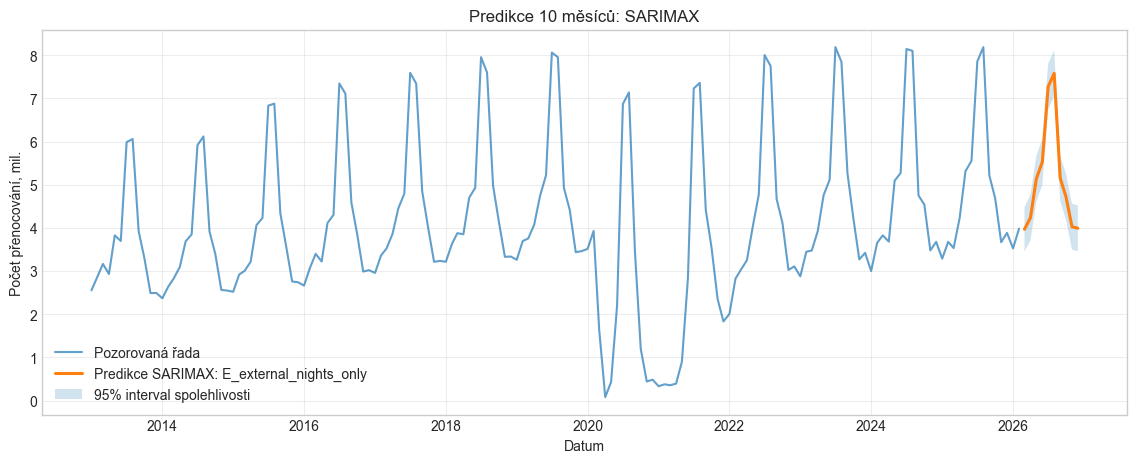

In [24]:
sarimax_forecast_res = best_fit.get_forecast(
    steps=future_steps,
    exog=future_exog_scaled,
)
sarimax_forecast = sarimax_forecast_res.summary_frame(alpha=0.05)
sarimax_forecast.index = future_index

display(forecast_table_millions(sarimax_forecast, "mean_ci_lower", "mean_ci_upper"))

plt.figure(figsize=(14, 5))
plt.plot(y.index, y / 1_000_000, label="Pozorovaná řada", alpha=0.7)
plt.plot(
    sarimax_forecast.index,
    sarimax_forecast["mean"] / 1_000_000,
    label=f"Predikce SARIMAX: {best_sarimax_name}",
    linewidth=2.2,
)
plt.fill_between(
    sarimax_forecast.index,
    sarimax_forecast["mean_ci_lower"] / 1_000_000,
    sarimax_forecast["mean_ci_upper"] / 1_000_000,
    alpha=0.2,
    label="95% interval spolehlivosti",
)
plt.title("Predikce 10 měsíců: SARIMAX")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()


Nakonec se zobrazí společné srovnání bodových predikcí. Cílem je posoudit, který model poskytuje prakticky nejrozumnější budoucí vývoj.


,Fourier_regression,SARIMA,SARIMAX
2026-03-01,3.794,4.393,3.969
2026-04-01,3.796,4.959,4.240
2026-05-01,4.595,5.588,5.138
2026-06-01,5.078,5.378,5.528
2026-07-01,8.103,6.154,7.272
2026-08-01,8.033,6.265,7.582
2026-09-01,5.259,4.302,5.158
2026-10-01,4.438,4.536,4.720
2026-11-01,3.524,3.719,4.026
2026-12-01,3.512,3.739,3.993


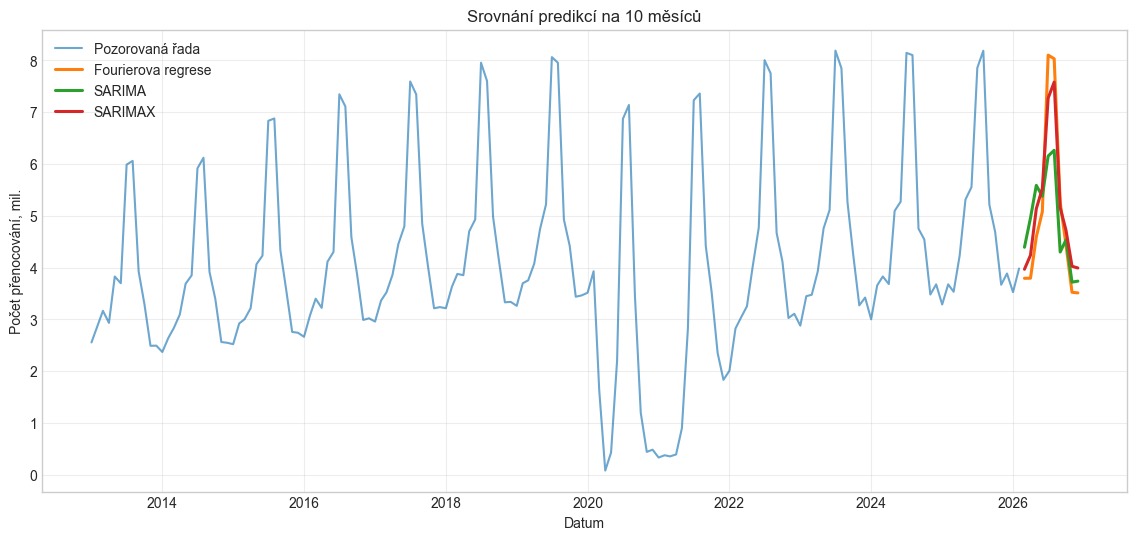

In [25]:
forecast_comparison = pd.DataFrame(
    {
        "Fourier_regression": fourier_forecast["mean"] / 1_000_000,
        "SARIMA": sarima_forecast["mean"] / 1_000_000,
        "SARIMAX": sarimax_forecast["mean"] / 1_000_000,
    },
    index=future_index,
)
display(forecast_comparison.round(3))

plt.figure(figsize=(14, 6))
plt.plot(y.index, y / 1_000_000, label="Pozorovaná řada", alpha=0.65)
plt.plot(
    fourier_forecast.index,
    fourier_forecast["mean"] / 1_000_000,
    label="Fourierova regrese",
    linewidth=2.2,
)
plt.plot(
    sarima_forecast.index,
    sarima_forecast["mean"] / 1_000_000,
    label="SARIMA",
    linewidth=2.2,
)
plt.plot(
    sarimax_forecast.index,
    sarimax_forecast["mean"] / 1_000_000,
    label="SARIMAX",
    linewidth=2.2,
)
plt.title("Srovnání predikcí na 10 měsíců")
plt.xlabel("Datum")
plt.ylabel("Počet přenocování, mil.")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()


**Interpretace predikcí.** Fourierova regrese vytváří velmi výraznou sezónní predikci, ale její rezidua jsou silně autokorelovaná. SARIMA pracuje pouze s minulostí hlavní řady a má širší intervaly, v některých případech i prakticky problematické dolní meze. SARIMAX poskytuje realističtější bodovou predikci a užší intervaly, protože využívá související turistické řady. Je však nutné zdůraznit, že SARIMAX predikce je podmíněná predikovanými externími regresory a její intervaly plně nezahrnují nejistotu těchto externích forecastů.


## 10. Závěrečné porovnání a závěr

Cílem práce bylo najít optimální model pro měsíční počet přenocování turistů v České republice. Zvolená řada je pro analýzu vhodná, protože má výraznou roční sezónnost, dlouhodobý vývoj a zároveň obsahuje mimořádné narušení během pandemie COVID-19.

Grafická analýza ukázala jasná letní maxima, zimní minima, růst před rokem 2020, silný propad v letech 2020-2021 a následné zotavení. STL dekompozice a 12měsíční klouzavý průměr tento závěr potvrdily: sezónnost je stabilní, zatímco trend byl výrazně narušen pandemickým obdobím.

Deterministické regresní modely ukázaly, že trend a sezónnost lze popsat poměrně dobře. Nejlepší variantou v této skupině byl Fourierův model s pěti harmonickými složkami, který flexibilně zachytil roční sezónní tvar. Tento model je však nedostatečný jako finální model, protože rezidua zůstala silně autokorelovaná podle ACF i Ljungova-Boxova testu.

Čistý SARIMA model lépe pracoval s autokorelací a sezónní závislostí hlavní řady. Přesto se ukázalo, že samotná historie řady nestačí: diagnostika reziduí stále ukazovala významnou autokorelaci, zejména na sezónních zpožděních. SARIMA je proto metodicky důležitým zlepšením proti deterministické regresi, ale v této práci není finálním nejlepším modelem.

Kroskorelační analýza po odstranění trendu, sezónnosti a COVID efektu ukázala silné současné vztahy mezi českou řadou a dalšími turistickými ukazateli. Nejvýraznější korelace byly při zpoždění 0, takže nebyla nalezena podstatná zpožděná závislost. Tento výsledek motivoval použití současných externích regresorů v SARIMAX modelu.

Nejlepším modelem z testovaných variant je SARIMAX s externími řadami přenocování v Německu, Polsku a na Slovensku a se strukturou chyb \(SARIMA(2,0,0)(0,0,2)_{12}\). Technické srovnání vychází ze souhrnné diagnostické tabulky: Fourierova regrese měla AIC přibližně 4636.85 a RMSE přibližně 522 tisíc, SARIMA po přefitování ve `statsmodels` měla AIC přibližně 4038.25 a RMSE přibližně 733 tisíc, zatímco SARIMAX dosáhl AIC přibližně 3663.14 a RMSE přibližně 206 tisíc. U SARIMAX modelu je Ljungův-Boxův test na zpoždění 12 již přijatelný na 5% hladině významnosti, ale na zpožděních 24 a 36 autokorelace stále zůstává, což je důležité omezení finálního modelu.

Predikční srovnání také podporuje SARIMAX. Fourierova regrese predikuje pro červenec a srpen 2026 přibližně 8.10 a 8.03 milionu přenocování, SARIMA přibližně 6.15 a 6.27 milionu a SARIMAX přibližně 7.27 a 7.58 milionu. SARIMA má širší intervaly a horší praktickou interpretovatelnost, zatímco SARIMAX poskytuje realističtější letní maximum a užší intervaly, protože využívá informace z příbuzných turistických řad.

Při interpretaci je nutné uvést několik omezení. Pandemické období je strukturální zlom, nikoli běžná náhodná fluktuace. AIC mezi různými rodinami modelů je třeba porovnávat opatrně, i když tabulky používají jednotný zdroj pro SARIMA/SARIMAX odhady. SARIMAX forecast závisí na predikovaných budoucích externích regresorech a jeho intervaly spolehlivosti plně nezahrnují nejistotu těchto externích predikcí. Další zlepšení by mohlo zahrnout explicitní intervenční model pro COVID období, robustnější modelování extrémních měsíců, alternativní sady externích proměnných nebo validační vyhodnocení na drženém koncovém období.

Celkově je jako nejlepší model vybrán **SARIMAX s externími regresory**, protože nejlépe kombinuje vysvětlení turistické závislosti na souvisejících řadách, řešení autokorelace a prakticky použitelnou predikci.


### Checklist splnění zadání

| Požadavek | Kde je řešen | Status |
|---|---|---|
| i) Grafické zobrazení řady a komentář | Kapitola 3 | Splněno |
| ii) Dekompozice a vyhlazení trendu | Kapitola 4 | Splněno |
| iii) Model pro samotnou řadu: trend, sezónnost, Fourierovy koeficienty | Kapitola 5 | Splněno |
| iv) Optimální SARIMA model | Kapitola 6 | Splněno |
| v) Kroskorelace a nalezení zpoždění závislosti | Kapitola 7 | Splněno |
| vi) Model s externími řadami a autokorelací | Kapitola 8 | Splněno |
| vii) Kontrola periody periodogramem | Kapitola 9.1 | Splněno |
| viii) Kontrola reziduí přes ACF / Ljung-Box | Kapitoly 5, 6, 8 a 9.2 | Splněno |
| ix) Predikce 10 budoucích pozorování s intervaly | Kapitola 9.3 | Splněno |
| x) Porovnání modelů a závěr | Kapitola 10 | Splněno |
